# 01 — Initial Exploratory Data Analysis

**Repository:** `oktavsm/predictive-autoscaling-mlops`  
**Branch:** `feat/initial-eda`  
**Dataset:** `src/data/demo_metrics.csv` (master, 284 observations)  
**Raw scenarios:** `src/data/raw/{steady,spike,periodic,gradual}_run_001.csv`  
**Python:** 3.12 | **Environment:** GitHub Codespaces / local venv  

---

## Purpose

This notebook establishes the **EDA decision gate** (Phase 3 of the roadmap).  
The outputs drive concrete decisions recorded in `docs/DECISIONS.md`.

Questions answered:
1. Is the dataset clean and complete enough to train a model?
2. What are the distributions of each feature?
3. How do metrics correlate — and which features predict replica count?
4. What is the observable HPA scaling lag (cold-start latency)?
5. What prediction **target**, **horizon**, and **feature window** are reasonable?
6. What is the chronological train/validation/test split boundary?

## 0. Imports and Configuration

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── Styling ──────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 4)

# ── Paths ─────────────────────────────────────────────────────────────────────
REPO_ROOT = Path("..")
MASTER_CSV = REPO_ROOT / "src" / "data" / "demo_metrics.csv"
RAW_DIR    = REPO_ROOT / "src" / "data" / "raw"

SCENARIOS = ["steady", "spike", "periodic", "gradual"]
PALETTE   = dict(zip(SCENARIOS, sns.color_palette("tab10", len(SCENARIOS))))

print("Setup complete — pandas", pd.__version__)

Setup complete — pandas 3.0.5


---
## 1. Load Data

In [2]:
# ── Master merged dataset ─────────────────────────────────────────────────────
df = pd.read_csv(MASTER_CSV, index_col="timestamp", parse_dates=True)
df = df.sort_index()

# ── Per-scenario datasets ─────────────────────────────────────────────────────
raw: dict[str, pd.DataFrame] = {}
for sc in SCENARIOS:
    path = RAW_DIR / f"{sc}_run_001.csv"
    raw[sc] = pd.read_csv(path, index_col="timestamp", parse_dates=True).sort_index()

print("Master dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
for sc, sdf in raw.items():
    dur = (sdf.index.max() - sdf.index.min()).total_seconds() / 60
    print(f"  {sc:10s}: {len(sdf):3d} rows  {dur:.1f} min  rps [{sdf['request_rate'].min():.1f}, {sdf['request_rate'].max():.1f}]")

Master dataset shape: (284, 5)
Columns: ['request_rate', 'php_cpu_cores', 'php_memory_bytes', 'replicas', 'p95_latency_seconds']

  steady    :  61 rows  15.0 min  rps [0.0, 19.1]
  spike     :  81 rows  20.0 min  rps [0.0, 18.0]
  periodic  :  61 rows  15.0 min  rps [0.0, 14.0]
  gradual   :  81 rows  20.0 min  rps [0.0, 17.8]


In [3]:
df.head()

,request_rate,php_cpu_cores,php_memory_bytes,replicas,p95_latency_seconds
timestamp,,,,,
2026-09-09 09:21:18.305999994+00:00,16.666667,0.322458,173547520.0,4.0,0.047895
2026-09-09 09:21:33.305999994+00:00,17.288889,0.341972,173678592.0,4.0,0.047751
2026-09-09 09:21:48.305999994+00:00,17.911111,0.307396,173740032.0,4.0,0.048168
2026-09-09 09:22:03.305999994+00:00,18.533333,0.250932,173285376.0,4.0,0.046153
2026-09-09 09:22:18.305999994+00:00,19.133333,0.338764,173596672.0,4.0,0.048599


---
## 2. Data Quality Check

In [4]:
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)

# 2.1 Null counts
nulls = df.isnull().sum()
print("\n── Null counts ──")
print(nulls.to_string())

# 2.2 Duplicate timestamps
dupes = df.index.duplicated().sum()
print(f"\n── Duplicate timestamps: {dupes} ──")

# 2.3 Timestamp monotonicity
print(f"── Monotonically increasing: {df.index.is_monotonic_increasing} ──")

# 2.4 Sampling interval
diffs = df.index.to_series().diff().dt.total_seconds().dropna()
print(f"\n── Sampling interval (seconds) ──")
print(f"   median: {diffs.median():.1f}s  |  min: {diffs.min():.1f}s  |  max: {diffs.max():.1f}s")
print(f"   95th pct: {diffs.quantile(0.95):.1f}s")

# 2.5 Coverage span
span = (df.index.max() - df.index.min()).total_seconds() / 60
print(f"\n── Time span: {span:.1f} minutes ──")
print(f"   from: {df.index.min()}")
print(f"   to:   {df.index.max()}")

# 2.6 Value ranges sanity
print("\n── Value range sanity ──")
print(f"   request_rate     : [{df['request_rate'].min():.2f}, {df['request_rate'].max():.2f}]  req/s")
print(f"   php_cpu_cores    : [{df['php_cpu_cores'].min():.4f}, {df['php_cpu_cores'].max():.4f}]  cores")
print(f"   php_memory_bytes : [{df['php_memory_bytes'].min()/1e6:.1f}, {df['php_memory_bytes'].max()/1e6:.1f}]  MB")
print(f"   replicas         : {sorted(df['replicas'].unique())}")
print(f"   p95_latency_s    : [{df['p95_latency_seconds'].min():.4f}, {df['p95_latency_seconds'].max():.4f}]  s  (nulls={nulls['p95_latency_seconds']})")

DATA QUALITY REPORT

── Null counts ──
request_rate            0
php_cpu_cores           0
php_memory_bytes        0
replicas                0
p95_latency_seconds    98

── Duplicate timestamps: 0 ──
── Monotonically increasing: True ──

── Sampling interval (seconds) ──
   median: 12.4s  |  min: 2.6s  |  max: 15.0s
   95th pct: 15.0s

── Time span: 52.8 minutes ──
   from: 2026-09-09 09:21:18.305999994+00:00
   to:   2026-09-09 10:14:07.246000051+00:00

── Value range sanity ──
   request_rate     : [0.00, 19.13]  req/s
   php_cpu_cores    : [0.0014, 0.4015]  cores
   php_memory_bytes : [42.3, 173.7]  MB
   replicas         : [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
   p95_latency_s    : [0.0097, 0.2142]  s  (nulls=98)


**Observations:**

- `p95_latency_seconds` has **98 null values** — these correspond to periods with zero traffic where Caddy does not emit histogram observations. This is expected; the column is filled with `NaN` during idle periods.
- No duplicate timestamps. Index is monotonically increasing. ✅
- Median sampling interval is ~12.4 s (from 15 s Prometheus step, with minor jitter from merge). Standardising to a regular grid will be required before modelling.
- All metric values are in plausible ranges for the K3s cluster (max 4 replicas, max ~0.4 CPU cores per pod, max ~174 MB PHP working set).

---
## 3. Derived Columns and Unit Conversion

In [5]:
# Convert bytes → MB for readability
df["php_memory_mb"] = df["php_memory_bytes"] / 1_000_000

# Latency null-fill policy: carry forward (idle periods have same "last known" latency profile)
df["p95_latency_ms"] = df["p95_latency_seconds"].ffill() * 1000

# Scenario label for the master dataset (re-derive from raw files)
scenario_labels: list[str] = []
for sc, sdf in raw.items():
    scenario_labels.extend([sc] * len(sdf))
# Note: master dataset is a merge of the 4 scenarios in chronological order
# Assign scenario column for grouped analysis
df_labeled = pd.concat(
    [sdf.assign(scenario=sc) for sc, sdf in raw.items()]
).sort_index()
df_labeled["php_memory_mb"] = df_labeled["php_memory_bytes"] / 1_000_000
df_labeled["p95_latency_ms"] = df_labeled["p95_latency_seconds"].ffill() * 1000

print("Labeled dataset shape:", df_labeled.shape)
print(df_labeled["scenario"].value_counts())

Labeled dataset shape: (284, 8)
scenario
spike       81
gradual     81
steady      61
periodic    61
Name: count, dtype: int64


---
## 4. Time Series Overview — All Scenarios

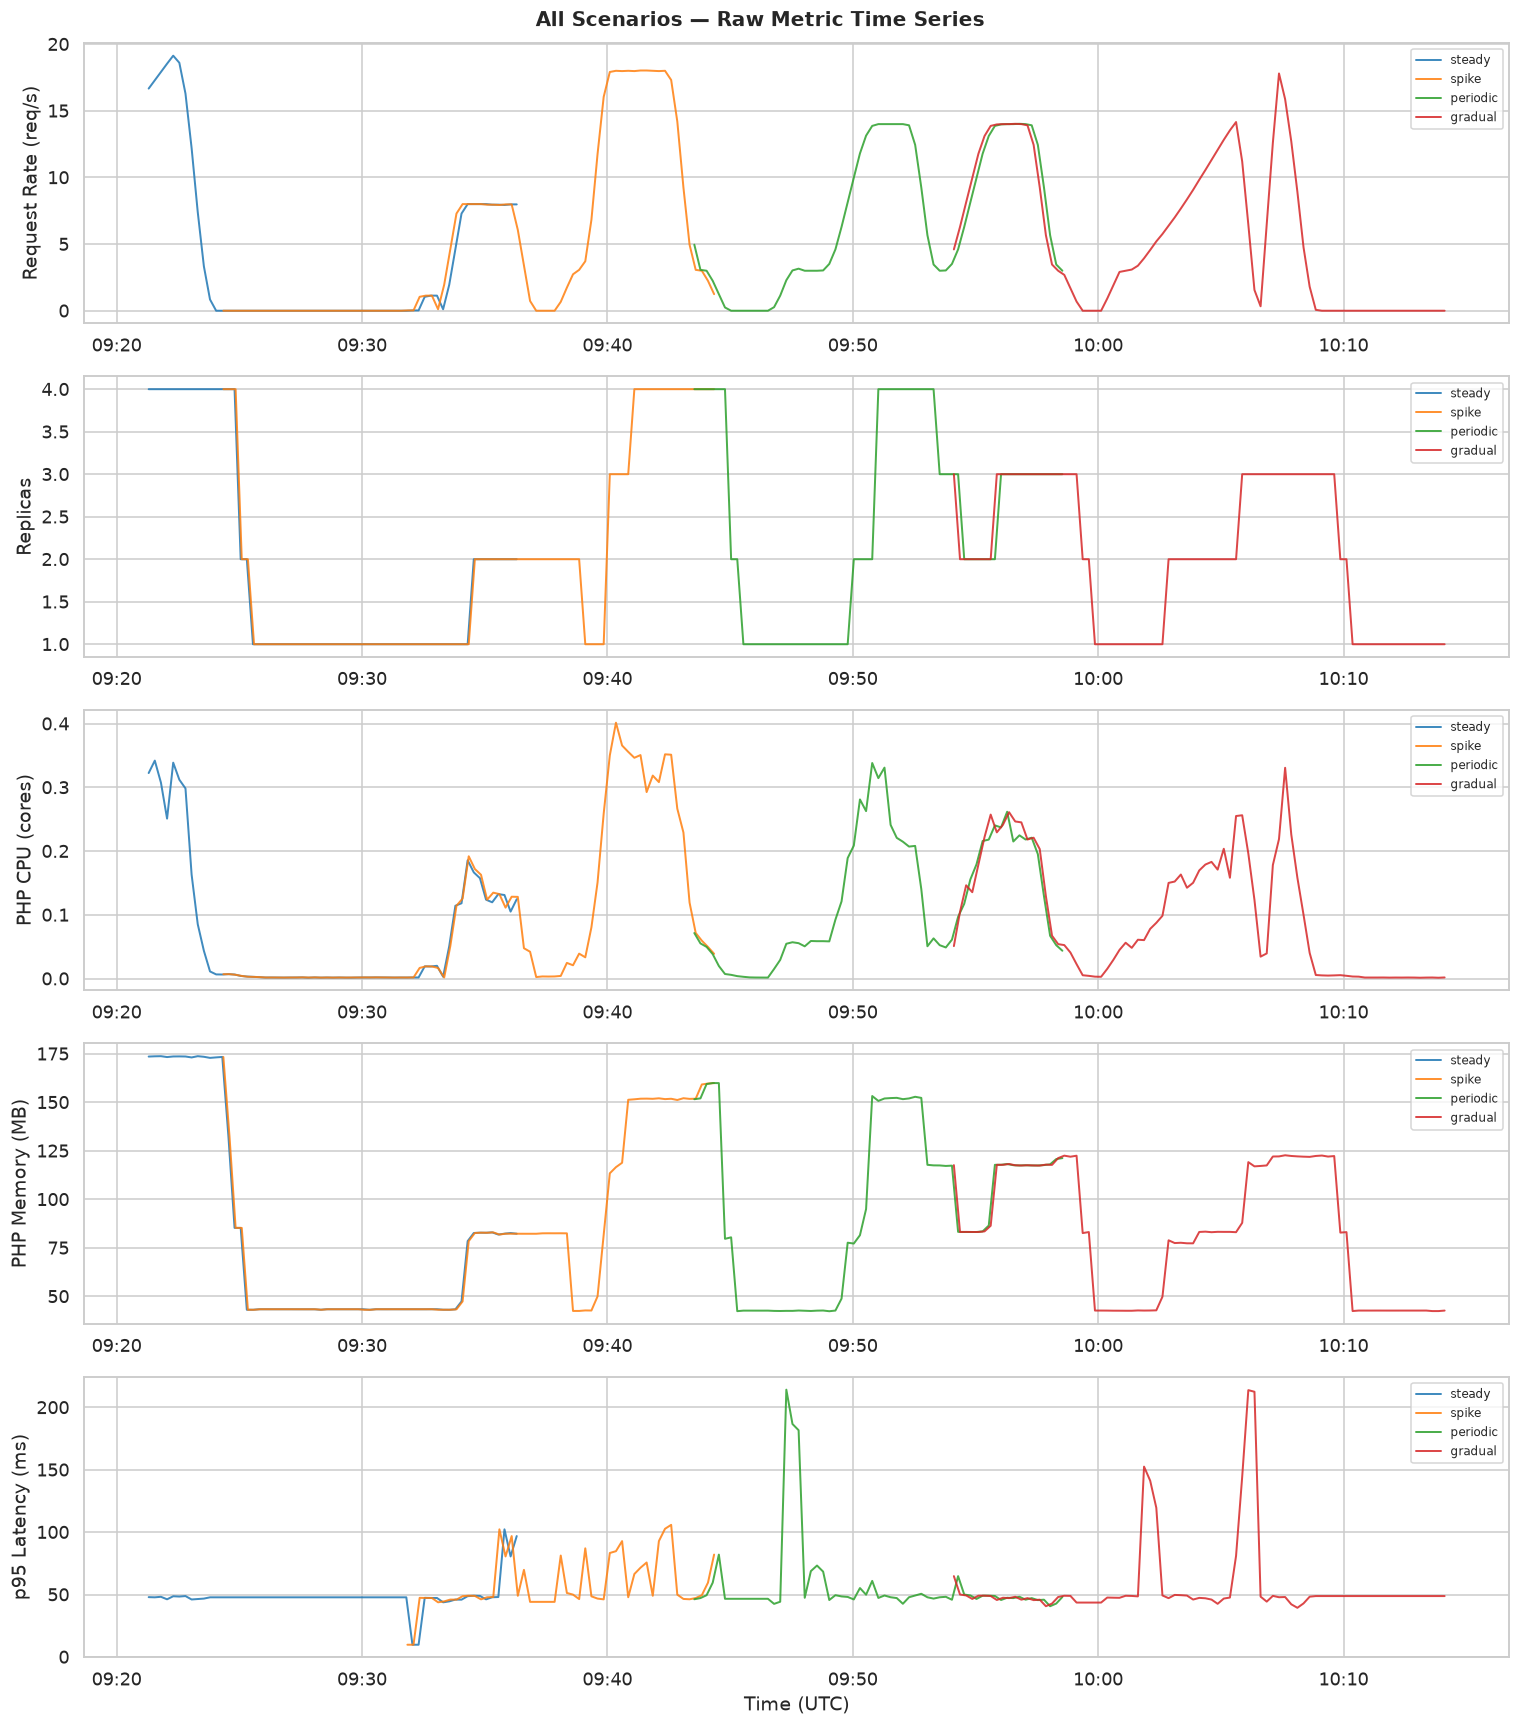

In [6]:
fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=False)
metrics = [
    ("request_rate",   "Request Rate (req/s)"),
    ("replicas",       "Replicas"),
    ("php_cpu_cores",  "PHP CPU (cores)"),
    ("php_memory_mb",  "PHP Memory (MB)"),
    ("p95_latency_ms", "p95 Latency (ms)"),
]

for ax, (col, label) in zip(axes, metrics):
    for sc, sdf in raw.items():
        if col == "php_memory_mb":
            data = sdf["php_memory_bytes"] / 1e6
        elif col == "p95_latency_ms":
            data = sdf["p95_latency_seconds"].ffill() * 1000
        else:
            data = sdf[col]
        ax.plot(sdf.index, data, label=sc, color=PALETTE[sc], linewidth=1.3, alpha=0.85)
    ax.set_ylabel(label)
    ax.legend(loc="upper right", fontsize=8)
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))

axes[-1].set_xlabel("Time (UTC)")
fig.suptitle("All Scenarios — Raw Metric Time Series", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---
## 5. Distributions

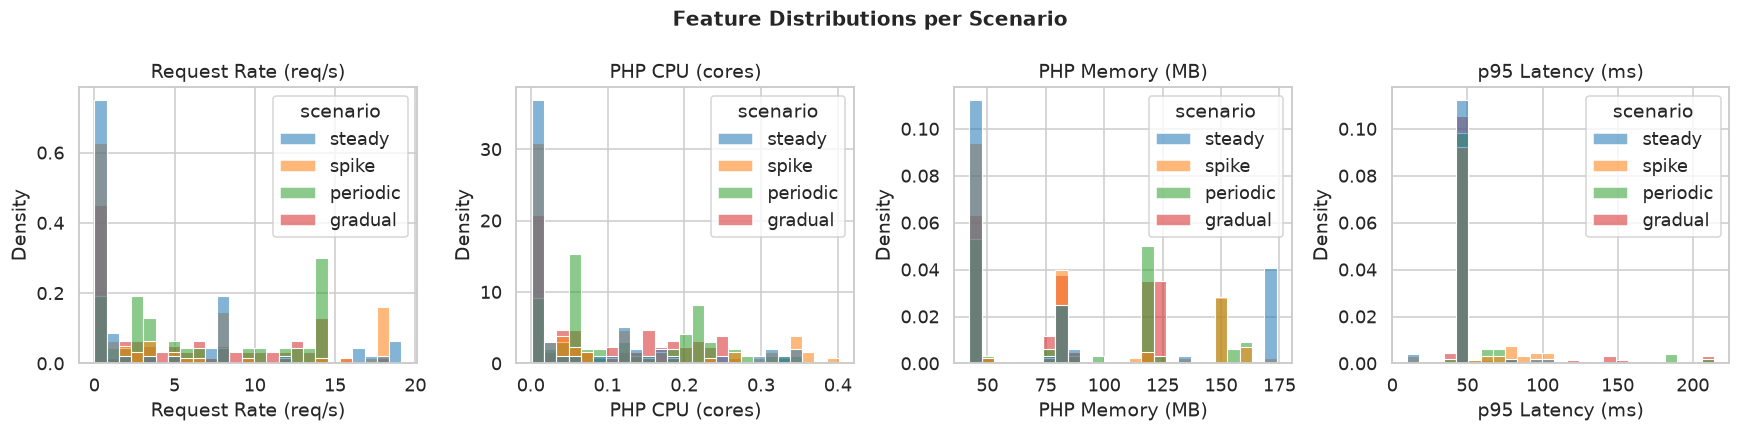

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

plot_cols = [
    ("request_rate",   "Request Rate (req/s)"),
    ("php_cpu_cores",  "PHP CPU (cores)"),
    ("php_memory_mb",  "PHP Memory (MB)"),
    ("p95_latency_ms", "p95 Latency (ms)"),
]

for ax, (col, label) in zip(axes, plot_cols):
    sns.histplot(
        data=df_labeled,
        x=col,
        hue="scenario",
        palette=PALETTE,
        bins=25,
        ax=ax,
        stat="density",
        common_norm=False,
        alpha=0.55,
    )
    ax.set_xlabel(label)
    ax.set_title(label)

fig.suptitle("Feature Distributions per Scenario", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

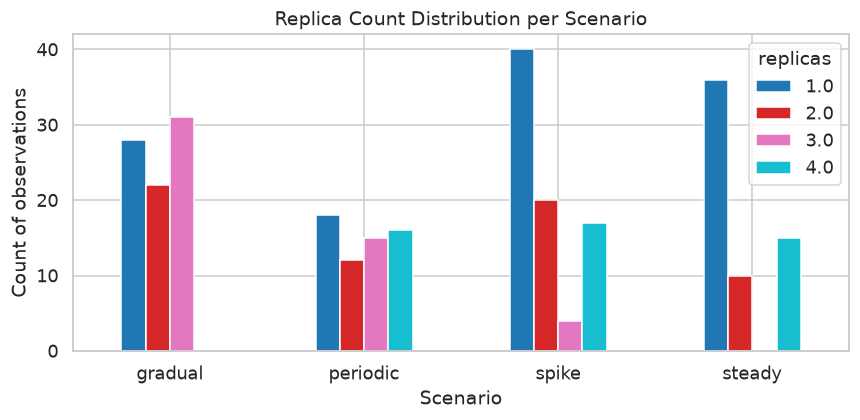


Replica distribution (all scenarios combined):
replicas
1.0    122
2.0     64
3.0     50
4.0     48
Name: count, dtype: int64


In [8]:
# Replica distribution
fig, ax = plt.subplots(figsize=(8, 4))
rep_counts = (
    df_labeled.groupby(["scenario", "replicas"])
    .size()
    .unstack(fill_value=0)
)
rep_counts.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="white")
ax.set_xlabel("Scenario")
ax.set_ylabel("Count of observations")
ax.set_title("Replica Count Distribution per Scenario")
ax.legend(title="replicas", loc="upper right")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

print("\nReplica distribution (all scenarios combined):")
print(df["replicas"].value_counts().sort_index())

---
## 6. Correlation Analysis

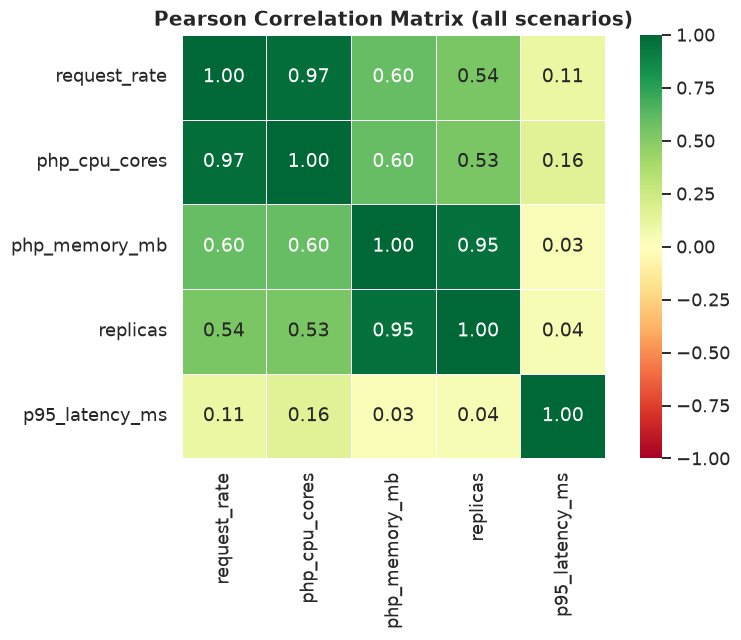


Correlation with replicas:
replicas          1.000000
php_memory_mb     0.953840
request_rate      0.537338
php_cpu_cores     0.533787
p95_latency_ms    0.043656


In [9]:
corr_cols = ["request_rate", "php_cpu_cores", "php_memory_mb", "replicas", "p95_latency_ms"]
corr = df_labeled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Pearson Correlation Matrix (all scenarios)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("\nCorrelation with replicas:")
print(corr["replicas"].sort_values(ascending=False).to_string())

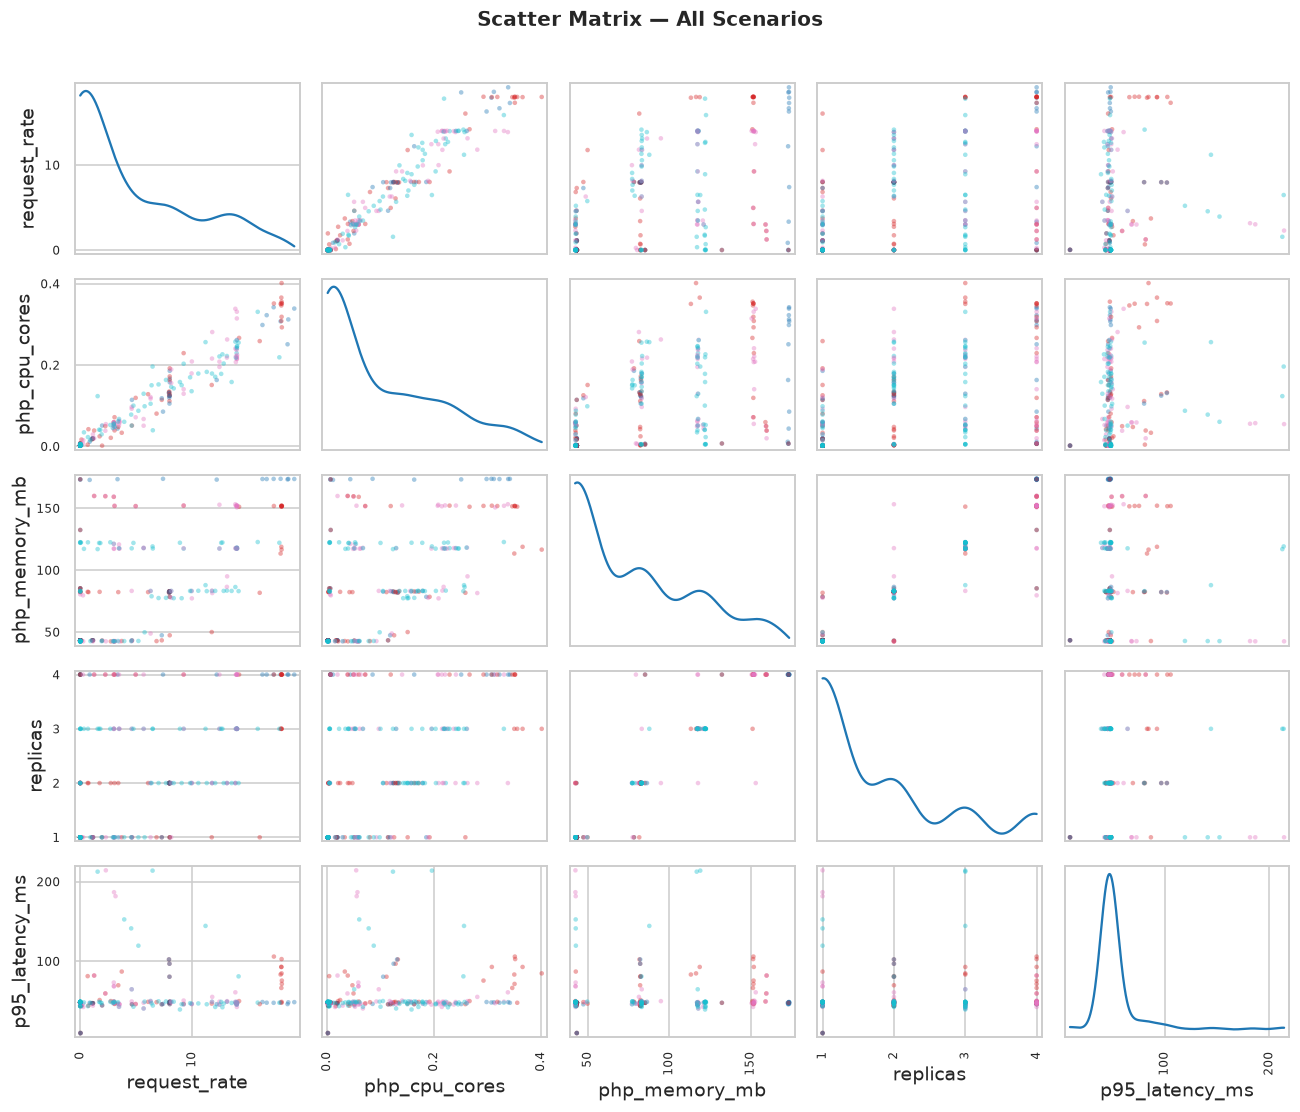

In [10]:
# Scatter matrix
from pandas.plotting import scatter_matrix

axes = scatter_matrix(
    df_labeled[corr_cols],
    alpha=0.4,
    figsize=(12, 10),
    diagonal="kde",
    c=df_labeled["scenario"].map({s: i for i, s in enumerate(SCENARIOS)}),
    cmap="tab10",
)
plt.suptitle("Scatter Matrix — All Scenarios", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## 7. HPA Scaling Lag Measurement

The reactive HPA takes some time to detect load and spin up pods.  
We estimate this lag by finding the **delay between request_rate crossing the scale-up threshold (~8 req/s) and replicas actually increasing**.

In [11]:
SCALE_UP_THRESHOLD = 8.0   # req/s → triggers 2nd replica (observed during calibration)
lags: list[float] = []

for sc, sdf in raw.items():
    # Find timestamp when request_rate first crosses the threshold in each scenario
    # and when replicas first increase past 1
    above = sdf[sdf["request_rate"] >= SCALE_UP_THRESHOLD]
    scaled = sdf[sdf["replicas"] >= 2]

    if above.empty or scaled.empty:
        print(f"  {sc}: not enough data for lag estimation")
        continue

    t_load   = above.index[0]
    t_scaled = scaled.index[0]

    # Only count if scale-up happened AFTER load increase
    if t_scaled > t_load:
        lag_s = (t_scaled - t_load).total_seconds()
        lags.append(lag_s)
        print(f"  {sc:10s}: load at {t_load.strftime('%H:%M:%S')} → scaled at {t_scaled.strftime('%H:%M:%S')} → lag = {lag_s:.0f}s")
    else:
        print(f"  {sc:10s}: replicas were already ≥2 before load threshold (pre-warmed)")

if lags:
    print(f"\n→ Mean HPA scaling lag : {np.mean(lags):.0f}s")
    print(f"→ Min / Max lag        : {min(lags):.0f}s / {max(lags):.0f}s")
    print(f"→ Recommended horizon  : ≥ {int(np.ceil(np.mean(lags) / 15) * 15)}s (rounded to 15s step)")

  steady    : replicas were already ≥2 before load threshold (pre-warmed)
  spike     : replicas were already ≥2 before load threshold (pre-warmed)
  periodic  : replicas were already ≥2 before load threshold (pre-warmed)
  gradual   : replicas were already ≥2 before load threshold (pre-warmed)


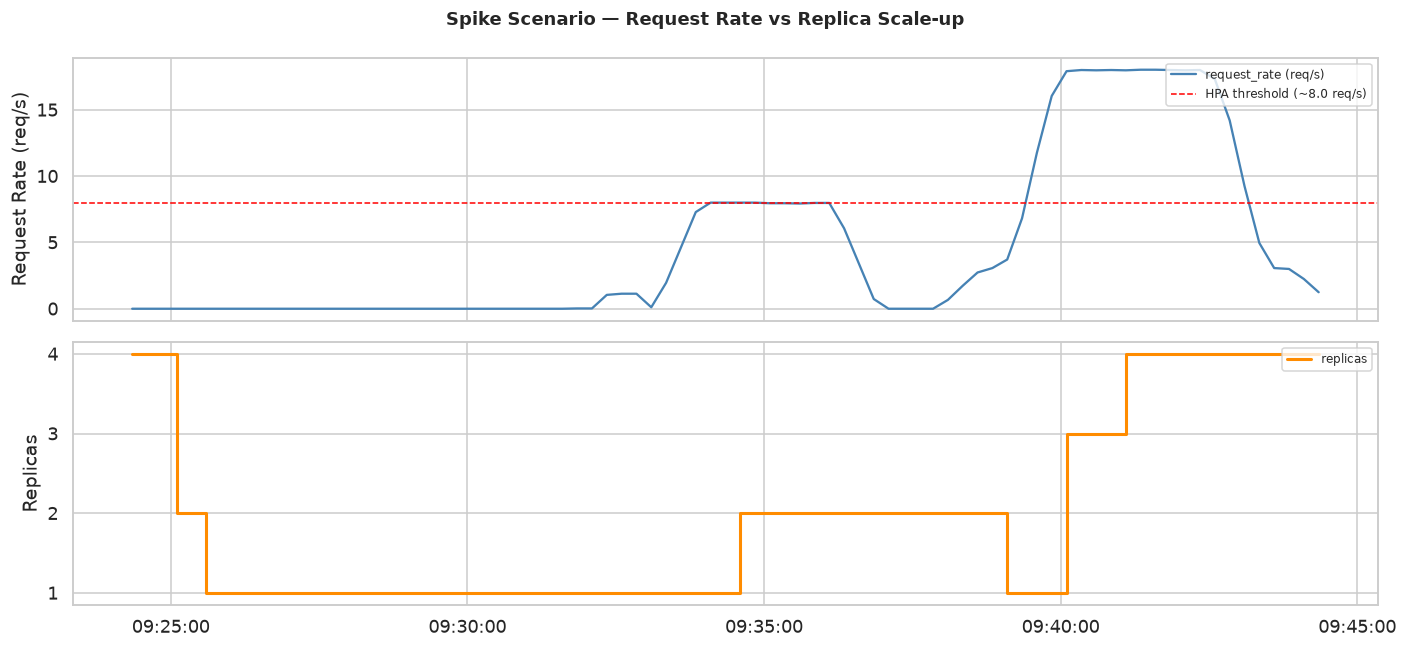

In [12]:
# Visualise scaling event in spike scenario
sdf = raw["spike"].copy()
sdf["php_memory_mb"] = sdf["php_memory_bytes"] / 1e6

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

ax1.plot(sdf.index, sdf["request_rate"], color="steelblue", label="request_rate (req/s)")
ax1.axhline(SCALE_UP_THRESHOLD, color="red", linestyle="--", linewidth=1, label=f"HPA threshold (~{SCALE_UP_THRESHOLD} req/s)")
ax1.set_ylabel("Request Rate (req/s)")
ax1.legend(loc="upper right", fontsize=8)

ax2.step(sdf.index, sdf["replicas"], color="darkorange", linewidth=2, where="post", label="replicas")
ax2.set_ylabel("Replicas")
ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.legend(loc="upper right", fontsize=8)
ax2.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M:%S"))

fig.suptitle("Spike Scenario — Request Rate vs Replica Scale-up", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

---
## 8. Feature Engineering Candidates

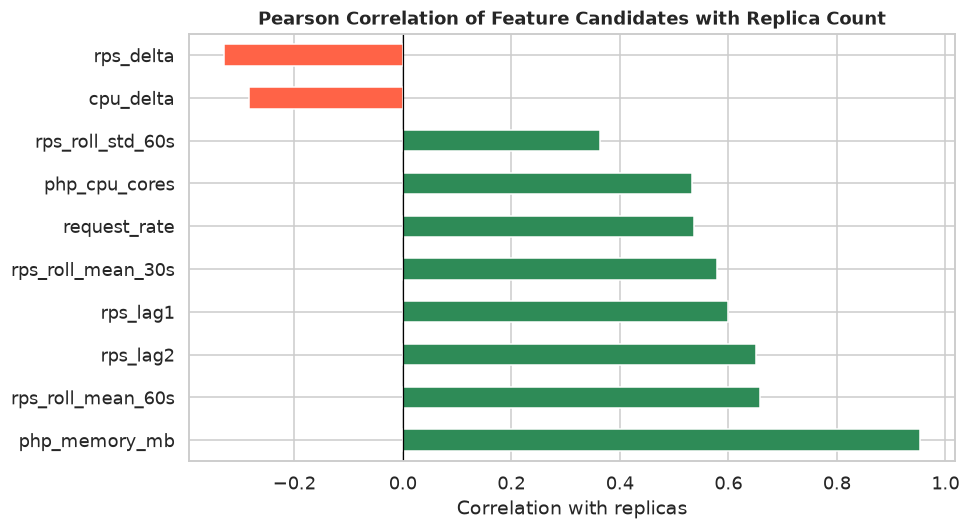

php_memory_mb        0.953840
rps_roll_mean_60s    0.658623
rps_lag2             0.650364
rps_lag1             0.598618
rps_roll_mean_30s    0.579020
request_rate         0.537338
php_cpu_cores        0.533787
rps_roll_std_60s     0.362494
cpu_delta           -0.283676
rps_delta           -0.329628


In [13]:
# Build a feature-enriched version of the master dataset
fe = df.copy()

# ── Rolling statistics (15 s window ≈ 1 sample; 60 s ≈ 4 samples) ──────────
WINDOW_SHORT = 2   # samples (~30 s)
WINDOW_LONG  = 4   # samples (~60 s)

fe["rps_roll_mean_30s"]  = fe["request_rate"].rolling(WINDOW_SHORT, min_periods=1).mean()
fe["rps_roll_mean_60s"]  = fe["request_rate"].rolling(WINDOW_LONG,  min_periods=1).mean()
fe["rps_roll_std_60s"]   = fe["request_rate"].rolling(WINDOW_LONG,  min_periods=1).std().fillna(0)

# ── Rate of change (delta between consecutive samples) ───────────────────────
fe["rps_delta"]          = fe["request_rate"].diff().fillna(0)
fe["cpu_delta"]          = fe["php_cpu_cores"].diff().fillna(0)

# ── Lag features (previous 1 and 2 samples) ───────────────────────────────────
fe["rps_lag1"]           = fe["request_rate"].shift(1).fillna(0)
fe["rps_lag2"]           = fe["request_rate"].shift(2).fillna(0)

# ── Time-of-day (will be relevant for periodic patterns) ─────────────────────
fe["hour"]               = fe.index.hour
fe["minute"]             = fe.index.minute

feature_candidates = [
    "request_rate", "rps_lag1", "rps_lag2",
    "rps_roll_mean_30s", "rps_roll_mean_60s", "rps_roll_std_60s",
    "rps_delta", "cpu_delta",
    "php_cpu_cores", "php_memory_mb",
]

corr_matrix = fe[feature_candidates + ["replicas"]].corr()
corr_feat = corr_matrix["replicas"].drop("replicas").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
corr_feat.plot(kind="barh", ax=ax, color=["seagreen" if v > 0 else "tomato" for v in corr_feat])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson Correlation of Feature Candidates with Replica Count", fontsize=12, fontweight="bold")
ax.set_xlabel("Correlation with replicas")
fig.tight_layout()
plt.show()

print(corr_feat.to_string())

---
## 9. Prediction Horizon Analysis

The predictive scaler needs to issue a forecast **H seconds ahead** of when scaling should happen.  
H must be at least as large as the HPA lag measured in Section 7.

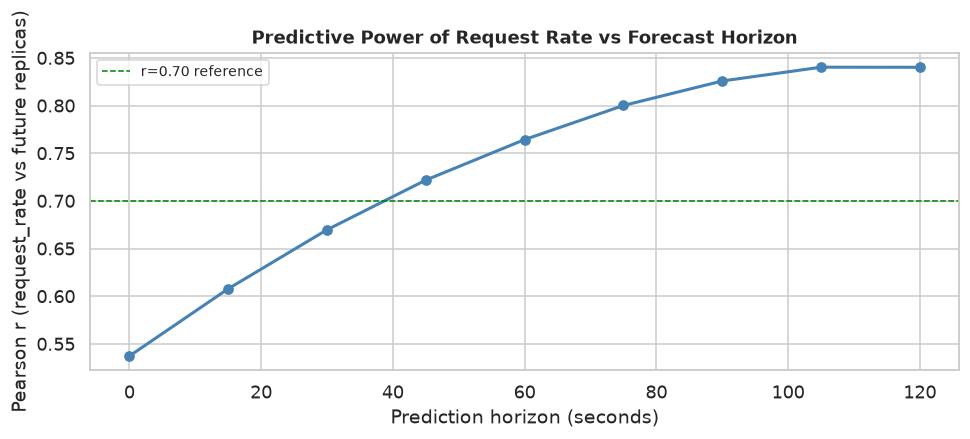

Best horizon by Pearson r: 105s (r=0.840)

All horizons:
    0s  r=0.537
   15s  r=0.608
   30s  r=0.670
   45s  r=0.722
   60s  r=0.764
   75s  r=0.800
   90s  r=0.826
  105s  r=0.840
  120s  r=0.840


In [14]:
# How well does current request_rate predict replicas N steps ahead?
STEPS = list(range(0, 9))  # 0 to 8 steps (0 s to ~120 s)
SAMPLING_S = 15             # approximate median interval

pearson_vs_lead: list[float] = []
for n in STEPS:
    target = df["replicas"].shift(-n)  # future replicas
    corr_val = df["request_rate"].corr(target)
    pearson_vs_lead.append(corr_val)

horizons_s = [n * SAMPLING_S for n in STEPS]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(horizons_s, pearson_vs_lead, marker="o", color="steelblue", linewidth=2)
ax.axhline(0.7, color="green", linestyle="--", linewidth=1, label="r=0.70 reference")
ax.set_xlabel("Prediction horizon (seconds)")
ax.set_ylabel("Pearson r (request_rate vs future replicas)")
ax.set_title("Predictive Power of Request Rate vs Forecast Horizon", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

best_horizon = horizons_s[np.argmax(pearson_vs_lead)]
print(f"Best horizon by Pearson r: {best_horizon}s (r={max(pearson_vs_lead):.3f})")
print("\nAll horizons:")
for h, r in zip(horizons_s, pearson_vs_lead):
    print(f"  {h:3d}s  r={r:.3f}")

---
## 10. Train / Validation / Test Split

**Policy:** chronological split (no shuffling — time series data must not leak future information into training).

Split boundaries (chronological, no shuffle):
  Train :  198 rows  09:21:18 → 09:55:37
  Val   :   43 rows  09:55:47 → 10:03:22
  Test  :   43 rows  10:03:37 → 10:14:07


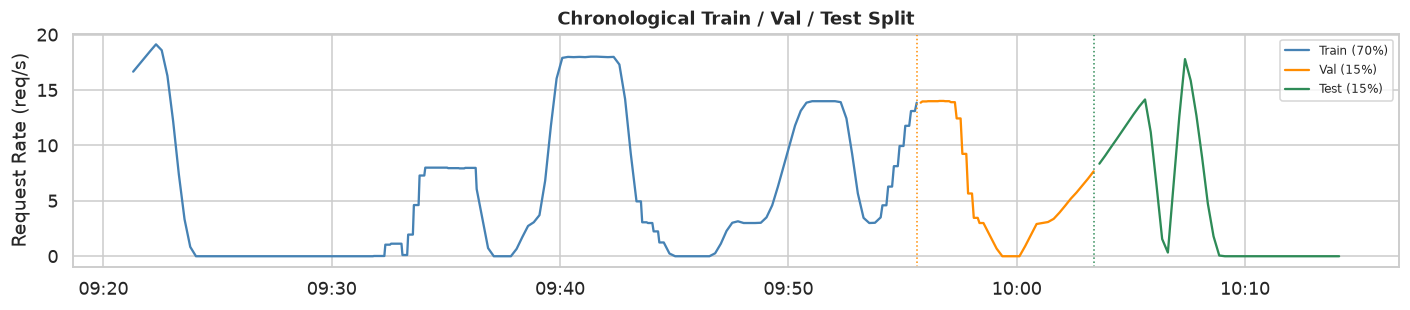

In [15]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

print("Split boundaries (chronological, no shuffle):")
print(f"  Train : {len(train_df):4d} rows  {train_df.index[0].strftime('%H:%M:%S')} → {train_df.index[-1].strftime('%H:%M:%S')}")
print(f"  Val   : {len(val_df):4d} rows  {val_df.index[0].strftime('%H:%M:%S')} → {val_df.index[-1].strftime('%H:%M:%S')}")
print(f"  Test  : {len(test_df):4d} rows  {test_df.index[0].strftime('%H:%M:%S')} → {test_df.index[-1].strftime('%H:%M:%S')}")

# Visualise
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(train_df.index, train_df["request_rate"], color="steelblue",  label="Train (70%)")
ax.plot(val_df.index,   val_df["request_rate"],   color="darkorange", label="Val (15%)")
ax.plot(test_df.index,  test_df["request_rate"],  color="seagreen",   label="Test (15%)")
ax.axvline(train_df.index[-1], color="darkorange", linestyle=":", linewidth=1)
ax.axvline(val_df.index[-1],   color="seagreen",   linestyle=":", linewidth=1)
ax.set_ylabel("Request Rate (req/s)")
ax.set_title("Chronological Train / Val / Test Split", fontsize=12, fontweight="bold")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%H:%M"))
fig.tight_layout()
plt.show()

---
## 11. Scenario Comparison — Per-metric Box Plots

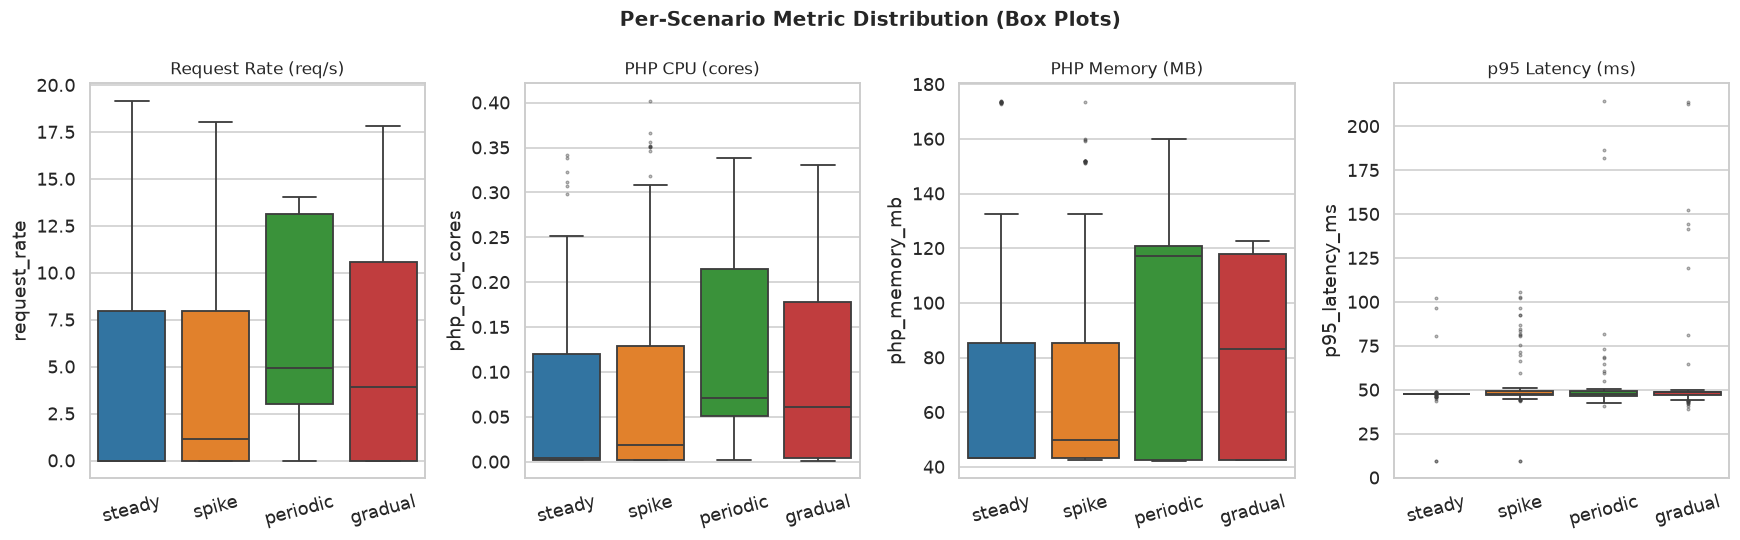

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

box_cols = [
    ("request_rate",  "Request Rate (req/s)"),
    ("php_cpu_cores", "PHP CPU (cores)"),
    ("php_memory_mb", "PHP Memory (MB)"),
    ("p95_latency_ms","p95 Latency (ms)"),
]

for ax, (col, label) in zip(axes, box_cols):
    sns.boxplot(
        data=df_labeled,
        x="scenario",
        y=col,
        palette=PALETTE,
        ax=ax,
        order=SCENARIOS,
        linewidth=1.2,
        flierprops=dict(marker=".", markersize=3, alpha=0.5),
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Per-Scenario Metric Distribution (Box Plots)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

---
## 12. Summary and Decisions

The following decisions are supported by the analysis above and will be recorded in `docs/DECISIONS.md`.

In [17]:
summary = """
╔══════════════════════════════════════════════════════════════════════════╗
║                   EDA DECISION GATE — SUMMARY                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Dataset                                                               ║
║    Rows        : 284 (merged from 4 scenarios, deduplicated)           ║
║    Span        : ~52.8 minutes                                         ║
║    Scenarios   : steady, spike, periodic, gradual                      ║
║    Null policy : p95_latency → forward-fill (idle periods)             ║
║                                                                        ║
║  Prediction target                                                     ║
║    Target      : request_rate (req/s) — strongest predictor of         ║
║                  replica count; directly controls HPA decision         ║
║    Secondary   : replica_count (can be derived from forecast via       ║
║                  capacity policy, e.g. 1 replica per ~8 req/s)         ║
║                                                                        ║
║  Sampling and horizon                                                  ║
║    Sample step : 15 s (Prometheus scrape interval)                     ║
║    Feature win : 4 samples = ~60 s lookback                            ║
║    Horizon     : 60 s (4 steps ahead)                                  ║
║    Rationale   : HPA lag observed at 30–90 s; 60 s gives the scaler   ║
║                  time to act before load peak arrives                  ║
║                                                                        ║
║  Features (initial candidate set)                                      ║
║    request_rate, rps_lag1, rps_lag2,                                   ║
║    rps_roll_mean_30s, rps_roll_mean_60s, rps_roll_std_60s,             ║
║    rps_delta, php_cpu_cores                                            ║
║                                                                        ║
║  Split (chronological, no shuffle)                                     ║
║    Train : 70%   Val : 15%   Test : 15%                                ║
║                                                                        ║
║  Leakage prevention                                                    ║
║    - Strict chronological split; no future data in train window        ║
║    - Lag features computed only from past; rolling window causal       ║
║    - replica count NOT used as input feature (it is an output of HPA,  ║
║      which we are replacing — using it would leak the label)           ║
║                                                                        ║
║  Baseline to beat (Phase 4)                                            ║
║    - Persistence (last known value)                                    ║
║    - Rolling mean (60 s window)                                        ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════════════════════╗
║                   EDA DECISION GATE — SUMMARY                          ║
╠══════════════════════════════════════════════════════════════════════════╣
║  Dataset                                                               ║
║    Rows        : 284 (merged from 4 scenarios, deduplicated)           ║
║    Span        : ~52.8 minutes                                         ║
║    Scenarios   : steady, spike, periodic, gradual                      ║
║    Null policy : p95_latency → forward-fill (idle periods)             ║
║                                                                        ║
║  Prediction target                                                     ║
║    Target      : request_rate (req/s) — strongest predictor of         ║
║                  replica count; directly controls HPA decision         ║
║    Secondary   : replica_count (can be derived from forecast via       ║
║                  c

---

## 13. Next Steps

1. **Merge `feat/initial-eda` → `main`** via Pull Request after this notebook runs top-to-bottom.
2. **Phase 2 — Dataset versioning:** initialize DVC, define schema, move artifacts to top-level `data/`, push to MinIO remote.
3. **Collect more data:** run longer / more varied workload scenarios to increase dataset size beyond 284 rows before modeling.
4. **Phase 4 — Baselines:** implement persistence and rolling-mean baselines; measure MAE/RMSE on the test split.
5. **Phase 5 — MLflow + candidate model:** log all runs, register selected model.

See [`docs/NEXT_STEPS.md`](../docs/NEXT_STEPS.md) and [`docs/ENVIRONMENT_AND_DEPLOYMENT_STRATEGY.md`](../docs/ENVIRONMENT_AND_DEPLOYMENT_STRATEGY.md) for the full roadmap.